In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation,FFMpegWriter
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd
from copy import deepcopy

In [12]:
def calcular_parametros(sim_data):
    """
    Calcula parámetros de separación, burbuja de recirculación y grosor de  capa límite
    a partir de los datos de simulación.
    Parámetros:
    - sim_data: diccionario con datos de simulación que contiene:
        - 'u_history': historial de velocidades (array 2D)
        - 'X_star': coordenadas X (array 2D)
        - 'Y_star': coordenadas Y (array 2D)
    Retorna:
    - x_sep: posición de separación (float)
    - bubble: tamaño de la burbuja de recirculación (float)
    - delta: grosor de la capa límite (float)
    """
    u_hist = sim_data['u_history']
    X = sim_data['X_star']
    Y = sim_data['Y_star']

    final_u = u_hist[-1]

    # Tomamos la línea más baja (y≈0)
    y_line_idx = 1  # la segunda fila desde abajo
    u_bottom = final_u[y_line_idx, :]
    x_vals = X[y_line_idx, :]

    # Buscar cambio de signo de positivo a negativo (indica separación)
    signo = np.sign(u_bottom)
    cambios = np.where(np.diff(signo) < 0)[0]

    x_sep = None
    if len(cambios) > 0:
        x_sep = x_vals[cambios[0]]
    
    # Buscar burbuja de recirculación (donde u < 0)
    indices_negativos = np.where(u_bottom < 0)[0]
    bubble = None
    if len(indices_negativos) > 1:
        bubble = x_vals[indices_negativos[-1]] - x_vals[indices_negativos[0]]

    # Calcular delta como grosor de la capa límite al final
    y_vals = Y[:, -1]  # columna más a la derecha
    u_profile = final_u[:, -1]
    u_inf = np.max(u_profile)
    delta = None
    for i in range(len(u_profile)):
        if u_profile[i] >= 0.99 * u_inf:
            delta = y_vals[i]
            break

    return x_sep, bubble, delta


# Convergencia

In [3]:
# Asegúrate de que calcular_parametros está definida antes de este bloque

# --- Configuración ---
carpeta = 'sim_separacion'
resoluciones = [25, 50, 100, 200, 400, 800]

# --- Resultados del análisis ---
resultados = []

def cargar_datos(resolucion):
    nombre_archivo = os.path.join(carpeta, f"{resolucion}x{resolucion}.pkl")
    with open(nombre_archivo, 'rb') as f:
        data = pickle.load(f)
    return data

# --- Carga y análisis de datos ---
for res in resoluciones:
    try:
        datos = cargar_datos(res)
        x_sep, bubble, delta = calcular_parametros(datos)
        resultados.append({
            'resolucion': res,
            'x_sep': x_sep,
            'bubble_size': bubble,
            'delta': delta
        })
    except Exception as e:
        print(f"❌ Error al procesar resolución {res}: {e}")

# --- Mostrar resultados individuales ---
for r in resultados:
    print(f"{r['resolucion']}x{r['resolucion']} -> "
          f"x_sep: {r['x_sep']}, bubble: {r['bubble_size']}, delta: {r['delta']}")

# --- Variables para análisis de convergencia ---
resoluciones_validas = [r['resolucion'] for r in resultados if r['delta'] is not None]
x_sep_vals = [r['x_sep'] for r in resultados if r['x_sep'] is not None]
bubble_vals = [r['bubble_size'] for r in resultados if r['bubble_size'] is not None]
delta_vals = [r['delta'] for r in resultados if r['delta'] is not None]


25x25 -> x_sep: 0.125, bubble: 0.8333333333333334, delta: 1.0
50x50 -> x_sep: 0.08163265306122448, bubble: 0.8979591836734694, delta: 1.0
100x100 -> x_sep: 0.04040404040404041, bubble: 0.9494949494949495, delta: 1.0
200x200 -> x_sep: 0.020100502512562814, bubble: 0.9748743718592965, delta: 1.0
400x400 -> x_sep: 0.010025062656641603, bubble: 0.987468671679198, delta: 1.0
800x800 -> x_sep: 0.0050062578222778474, bubble: 0.9937421777221527, delta: 0.9987484355444306


# Representacion de la convergencia

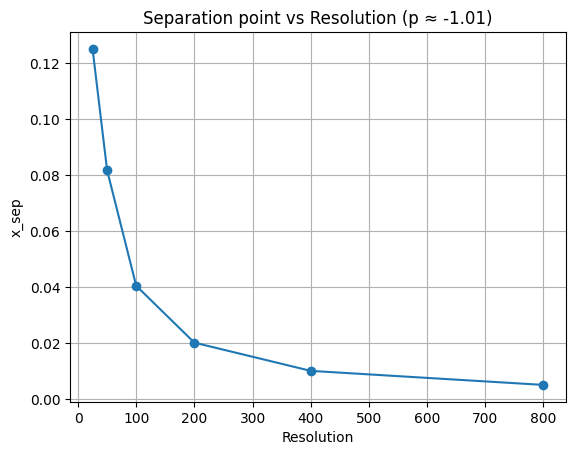

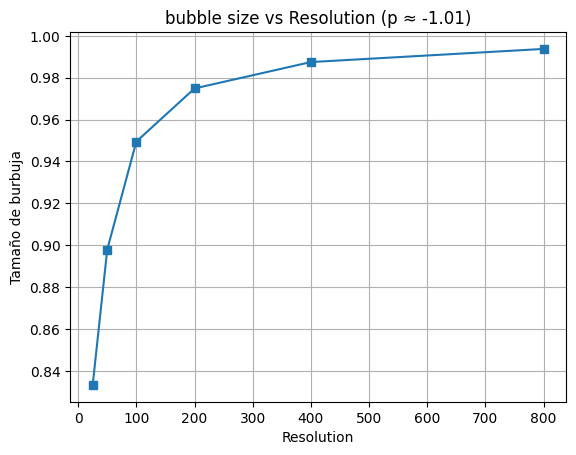

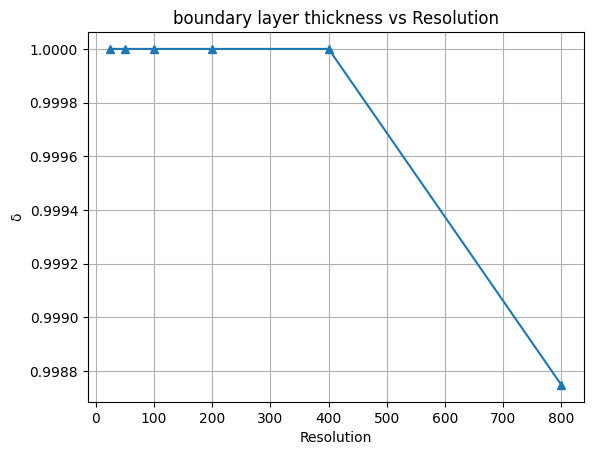

In [4]:
# Datos obtenidos
resoluciones = [25, 50, 100, 200, 400, 800]

# Función para calcular orden de convergencia
def orden_convergencia(f1, f2, f3, r):
    return np.log((f3 - f2) / (f2 - f1)) / np.log(r)

# Calcular orden de convergencia (solo con los 3 valores más refinados)
r = 2
p_xsep = orden_convergencia(x_sep_vals[2], x_sep_vals[3], x_sep_vals[4], r)
p_bubble = orden_convergencia(bubble_vals[2], bubble_vals[3], bubble_vals[4], r)

# delta es casi constante; su orden no es confiable
delta_casi_constante = all(np.isclose(d, 1.0) for d in delta_vals[:-1])
p_delta = None if delta_casi_constante else orden_convergencia(delta_vals[2], delta_vals[3], delta_vals[4], r)

# Gráfica para x_sep
plt.figure()
plt.plot(resoluciones, x_sep_vals, marker='o')
plt.title(f'Separation point vs Resolution (p ≈ {p_xsep:.2f})')
plt.xlabel('Resolution')
plt.ylabel('x_sep')
plt.grid()

# Gráfica para tamaño de burbuja
plt.figure()
plt.plot(resoluciones, bubble_vals, marker='s')
plt.title(f'bubble size vs Resolution (p ≈ {p_bubble:.2f})')
plt.xlabel('Resolution')
plt.ylabel('Tamaño de burbuja')
plt.grid()

# Gráfica para delta
plt.figure()
plt.plot(resoluciones, delta_vals, marker='^')
title = 'boundary layer thickness vs Resolution'
if p_delta is not None:
    title += f' (p ≈ {p_delta:.2f})'
plt.title(title)
plt.xlabel('Resolution')
plt.ylabel('δ')
plt.grid()

plt.show()


# DATA ASSIMILATION

In [ ]:
#============FUNCIONES PARA LA SIMULACION=============

@njit(parallel=True, fastmath=True)
def actualizar_campos(presion_adversa, u_old, v_old, p_old, T_old, u_star, v_star, p_star, T_star,
                      Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny):
    """    Actualiza los campos de velocidad, presión y temperatura usando el método de diferencias finitas.
    Parámetros:
    - presion_adversa: presión adversa aplicada en la entrada
    - u_old, v_old, p_old, T_old: campos antiguos de velocidad, presión y temperatura
    - u_star, v_star, p_star, T_star: campos actualizados de velocidad, presión y temperatura
    - Re, Pr, Ec, Eu: números adimensionales
    - dt_star: paso de tiempo adimensional
    - dx_star, dy_star: pasos espaciales adimensionales
    - nx, ny: dimensiones de la malla
    Retorna:
    - u_star, v_star, p_star, T_star: campos actualizados
    """

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_u_x = u_old[i, j] * (u_old[i, j + 1] - u_old[i, j - 1]) / (2 * dx_star)
            conv_u_y = v_old[i, j] * (u_old[i + 1, j] - u_old[i - 1, j]) / (2 * dy_star)
            diff_u_x = (u_old[i, j + 1] - 2 * u_old[i, j] + u_old[i, j - 1]) / dx_star**2
            diff_u_y = (u_old[i + 1, j] - 2 * u_old[i, j] + u_old[i - 1, j]) / dy_star**2
            u_star[i, j] += dt_star * (-conv_u_x - conv_u_y + (1 / Re) * (diff_u_x + diff_u_y))

            conv_v_x = u_old[i, j] * (v_old[i, j + 1] - v_old[i, j - 1]) / (2 * dx_star)
            conv_v_y = v_old[i, j] * (v_old[i + 1, j] - v_old[i - 1, j]) / (2 * dy_star)
            diff_v_x = (v_old[i, j + 1] - 2 * v_old[i, j] + v_old[i, j - 1]) / dx_star**2
            diff_v_y = (v_old[i + 1, j] - 2 * v_old[i, j] + v_old[i - 1, j]) / dy_star**2
            grad_p_y = (p_old[i + 1, j] - p_old[i - 1, j]) / (2 * dy_star)
            v_star[i, j] += dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1 / Re) * (diff_v_x + diff_v_y))

    for _ in range(20):
        for i in prange(1, ny - 1):
            for j in prange(1, nx - 1):
                div = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star) + \
                      (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
                p_star[i, j] = 0.25 * (p_old[i + 1, j] + p_old[i - 1, j] +
                                       p_old[i, j + 1] + p_old[i, j - 1] -
                                       (dx_star * dy_star) / (2 * (dx_star**2 + dy_star**2)) * div)
    
    # Gradiente de presión controlado
    for j in prange(nx):
        x = j * dx_star
        for i in prange(ny):
            if x <= 0.3:
                p_star[i, j] += 0.01  # presión constante en entrada
            else:
                p_star[i, j] += presion_adversa * (x - 0.3)


    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            u_star[i, j] -= dt_star * Eu * (p_star[i, j + 1] - p_star[i, j - 1]) / (2 * dx_star)
            v_star[i, j] -= dt_star * Eu * (p_star[i + 1, j] - p_star[i - 1, j]) / (2 * dy_star)

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_T_x = u_star[i, j] * (T_old[i, j + 1] - T_old[i, j - 1]) / (2 * dx_star)
            conv_T_y = v_star[i, j] * (T_old[i + 1, j] - T_old[i - 1, j]) / (2 * dy_star)
            diff_T_x = (T_old[i, j + 1] - 2 * T_old[i, j] + T_old[i, j - 1]) / dx_star**2
            diff_T_y = (T_old[i + 1, j] - 2 * T_old[i, j] + T_old[i - 1, j]) / dy_star**2
            Sxx = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star)
            Syy = (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
            Sxy = 0.5 * ((u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star) +
                         (v_star[i, j + 1] - v_star[i, j - 1]) / (2 * dx_star))
            viscous_heating = (Ec / Re) * (2 * (Sxx**2 + Syy**2) + 4 * Sxy**2)
            T_star[i, j] += dt_star * (-conv_T_x - conv_T_y +
                                       (1 / (Re * Pr)) * (diff_T_x + diff_T_y) +
                                       viscous_heating)

    tau = np.zeros((ny, nx))
    for i in prange(1, ny - 1):
        for j in prange(nx):
            tau[i, j] = (u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star)

# Condiciones de frontera
    v_star[0, :] = 0
    v_star[-1, :] = 0
    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0
    u_star[:, -1] = u_star[:, -2]
    p_star[:, 0] = p_star[:, 1]
    p_star[:, -1] = p_star[:, -2]
    p_star[0, :] = p_star[1, :]
    p_star[-1, :] = p_star[-2, :]

    return u_star, v_star, p_star, T_star, tau

def extraer_observaciones(N_sens=10, T_sens=5, size=800, carpeta="sim_separacion", ruido_std=0.0, seed=None):
    """
    Extrae observaciones de temperatura, presión y esfuerzo cortante de un archivo pickle.
    Parámetros:
    - N_sens: número de sensores a lo largo de la línea
    - T_sens: número de frames a extraer
    - size: tamaño de la simulación (e.g. 800 para 800x800)
    - carpeta: directorio donde se encuentran los datos
    - ruido_std: desviación estándar del ruido gaussiano a añadir a las observaciones
    - seed: semilla para reproducibilidad (opcional)
    """

    if seed is not None:
        np.random.seed(seed)

    path = os.path.join(carpeta, f"{size}x{size}.pkl")
    with open(path, "rb") as f:
        datos = pickle.load(f)

    T_hist = datos["T_history"]
    p_hist = datos["p_history"]
    tau_hist = datos["tau_history"]

    nt = len(T_hist)
    y_idx = 0.001  # y=0 línea inferior
    x_physical = np.linspace(0, 1, N_sens)

    observaciones = []
    frame_indices = np.linspace(0, nt - 1, T_sens, dtype=int)

    for t in frame_indices:
        T_line = T_hist[t][y_idx, :]
        p_line = p_hist[t][y_idx, :]
        tau_line = tau_hist[t][y_idx, :]
        nx = T_line.shape[0]

        x_idx_fine = (x_physical * (nx - 1)).astype(int)

        obs_t = {
            "t": t,
            "x_phys": x_physical,
            "T": T_line[x_idx_fine].copy(),
            "p": p_line[x_idx_fine].copy(),
            "tau": tau_line[x_idx_fine].copy()
        }

        if ruido_std > 0.0:
            obs_t["T"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["p"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["tau"] += np.random.normal(0, ruido_std, size=N_sens)

        observaciones.append(obs_t)

    return observaciones


# FUNCIONES PARA ANALISIS DE RESULTADOS

In [9]:
def calcular_rmse(campo_estimado, campo_referencia):
    """
    Calcula el RMSE medio por frame entre dos listas de campos (e.g. T).
    """
    errores = []
    for c_est, c_ref in zip(campo_estimado, campo_referencia):
        err = np.sqrt(np.mean((c_est - c_ref)**2))
        errores.append(err)
    return np.array(errores)


def comparar_resultados(resultados_base, resultados_dict, resultados_ref, variable='T'):
    """
    Compara el RMSE temporal entre una simulación base y múltiples métodos de asimilación.

    Parámetros:
    - resultados_base: dict con historial sin asimilación
    - resultados_dict: dict de resultados con asimilación {nombre_metodo: resultados}
    - resultados_ref: dict de referencia (ground truth)
    - variable: 'T', 'p', 'tau', etc.
    """
    var_map = {
        'T': 'T_history',
        'p': 'p_history',
        'u': 'u_history',
        'v': 'v_history',
        'tau': 'tau_history'
    }
    var_key = var_map[variable]

    # Historial de la base y la referencia
    hist_base = resultados_base[var_key]
    hist_ref = resultados_ref[var_key]

    # Calcular RMSE para cada método
    plt.figure(figsize=(10, 5))
    rmse_base = calcular_rmse(hist_base, hist_ref)
    plt.plot(rmse_base, label='Sin asimilación', linestyle='--')

    for nombre_metodo, resultados in resultados_dict.items():
        if var_key not in resultados:
            print(f"⚠️  {nombre_metodo} no contiene la variable '{variable}'")
            continue
        hist_asim = resultados[var_key]
        rmse_asim = calcular_rmse(hist_asim, hist_ref)
        plt.plot(rmse_asim, label=nombre_metodo)

    plt.title(f"RMSE temporal para {variable}")
    plt.xlabel("Timestep")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def animar_comparacion(base_data, asim_data, ref_data, variable='T'):
    """
    Animación con:
    [0] Simulación sin asimilación
    [1] Simulación con asimilación
    [2] Error absoluto entre asimilación y referencia

    Solo se muestra el título general con la magnitud y el instante de tiempo.
    """
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation

    # Mapeo de clave a historial
    var_map = {
        'T': 'T_history',
        'p': 'p_history',
        'u': 'u_history',
        'v': 'v_history',
        'tau': 'tau_history'
    }

    nombres = {
        'T': 'Temperatura',
        'p': 'Presión',
        'u': 'Velocidad u',
        'v': 'Velocidad v',
        'tau': 'Esfuerzo cortante'
    }

    assert variable in var_map, f"Variable '{variable}' no válida"
    var_key = var_map[variable]
    nombre_var = nombres.get(variable, variable)

    X = base_data["X_star"]
    Y = base_data["Y_star"]
    base_hist = base_data[var_key]
    asim_hist = asim_data[var_key]
    ref_hist = ref_data[var_key]

    nframes = min(len(base_hist), len(asim_hist), len(ref_hist))
    dt_star = base_data["params"]["dt_star"]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
    titles = [
        "Sin Asimilación",
        "Con Asimilación",
        "Error Abs. (Asimilado - Verdad)"
    ]
    cmaps = ['jet', 'jet', 'hot']
    colorbars = [None] * 3

    def plot_frame(frame_idx):
        datasets = [
            base_hist[frame_idx],
            asim_hist[frame_idx],
            np.abs(asim_hist[frame_idx] - ref_hist[frame_idx])
        ]

        for i, (ax, title, cmap, data) in enumerate(zip(axs, titles, cmaps, datasets)):
            ax.clear()
            cf = ax.contourf(X, Y, data, levels=20, cmap=cmap)
            ax.set_title(title)
            ax.set_xlabel("x*")
            ax.set_ylabel("y*")
            if colorbars[i] is None:
                colorbars[i] = plt.colorbar(cf, ax=ax)

    def update(frame):
        plot_frame(frame)
        fig.suptitle(
            f"Comparación de {nombre_var} ({variable}*) | t* = {frame / (nframes - 1):.2f}",
            fontsize=16
        )
        return axs

    plot_frame(0)
    fig.suptitle(f"Comparación de {nombre_var} ({variable}*)", fontsize=16)
    anim = FuncAnimation(fig, update, frames=nframes, interval=150, blit=False)
    plt.tight_layout()
    return anim, fig



def interpolar_historial(hist_ref, X_ref, Y_ref, X_dest, Y_dest):
    """
    Interpola una lista de campos 2D desde una malla de alta resolución (X_ref, Y_ref)
    a una malla objetivo (X_dest, Y_dest).
    """
    ny_ref, nx_ref = X_ref.shape
    ny_dest, nx_dest = X_dest.shape

    x_ref = np.linspace(0, 1, nx_ref)
    y_ref = np.linspace(0, 1, ny_ref)

    x_dest = np.linspace(0, 1, nx_dest)
    y_dest = np.linspace(0, 1, ny_dest)
    Xq, Yq = np.meshgrid(x_dest, y_dest)
    puntos_destino = np.stack([Yq.ravel(), Xq.ravel()], axis=-1)

    historial_interp = []
    for campo in hist_ref:
        interpolador = RegularGridInterpolator((y_ref, x_ref), campo)
        campo_interp = interpolador(puntos_destino).reshape(ny_dest, nx_dest)
        historial_interp.append(campo_interp)

    return historial_interp

def interpolar_resultados_completos(resultados_ref, resultados_destino):
    """
    Interpola todos los campos de resultados_ref a la malla de resultados_destino.
    Devuelve un nuevo diccionario 'resultados_ref_interp' con T, p, u, v, tau adaptados.
    """
    campos = ['T_history', 'p_history', 'u_history', 'v_history', 'tau_history']
    X_ref = resultados_ref['X_star']
    Y_ref = resultados_ref['Y_star']
    X_dest = resultados_destino['X_star']
    Y_dest = resultados_destino['Y_star']

    resultados_ref_interp = resultados_ref.copy()
    for campo in campos:
        resultados_ref_interp[campo] = interpolar_historial(
            resultados_ref[campo], X_ref, Y_ref, X_dest, Y_dest
        )

    # ✅ Mallas de destino (para evitar errores de shape en animaciones)
    resultados_ref_interp["X_star"] = X_dest
    resultados_ref_interp["Y_star"] = Y_dest


    return resultados_ref_interp

def comparar_lineas_corriente(resultados_dict, resultados_base, resultados_ref, y_linea=0.05):
    """
    Dibuja la línea de corriente que contiene a la burbuja de separación
    para cada método (incluyendo sin asimilación y referencia).
    """
    plt.figure(figsize=(10, 5))
    y_idx = int(y_linea * resultados_base['ny'])  # índice aproximado en y

    todos = {'Sin Asimilación': resultados_base, **resultados_dict, 'Referencia': resultados_ref}
    colores = ['k', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'gray']
    linestyles = ['--', '-', '-', '-', '-', ':']

    for (nombre, datos), color, ls in zip(todos.items(), colores, linestyles):
        X = datos["X_star"]
        Y = datos["Y_star"]
        u = datos["u_history"][-1]
        v = datos["v_history"][-1]

        # Línea de corriente por seed en la base
        start_x = np.linspace(0.05, 0.95, 8)
        start_y = np.ones_like(start_x) * y_linea

        plt.streamplot(X[0], Y[:, 0], u, v, color=color, linewidth=1.2,
                       start_points=np.column_stack([start_x, start_y]),
                       integration_direction='forward',
                       density=1.2,
                       arrowsize=1,
                       linestyle=ls,
                       label=nombre)

    plt.title("Líneas de corriente cerca de la pared inferior")
    plt.xlabel("x*")
    plt.ylabel("y*")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def mostrar_tiempos_asimilacion(resultados_dict):
    """
    Imprime los tiempos de asimilación registrados por cada método.
    """
    print("⏱️  Tiempos de asimilación por método:")
    for nombre, resultados in resultados_dict.items():
        tiempo = resultados.get("asimilacion_time", None)
        if tiempo is not None:
            print(f"   - {nombre:10s}: {tiempo:.2f} segundos")
        else:
            print(f"   - {nombre:10s}: (no registrado)")


def calcular_parametros_por_frame(sim_data):
    """
    Calcula la evolución temporal de:
    - x_sep: punto de separación
    - bubble: tamaño de la burbuja
    - delta: grosor de capa límite
    """
    u_hist = sim_data['u_history']
    X = sim_data['X_star']
    Y = sim_data['Y_star']

    x_vals = X[1, :]
    y_vals = Y[:, -1]

    x_sep_list = []
    bubble_list = []
    delta_list = []

    for u in u_hist:
        # Línea inferior para separación
        u_bottom = u[1, :]
        signo = np.sign(u_bottom)
        cambios = np.where(np.diff(signo) < 0)[0]
        x_sep = x_vals[cambios[0]] if len(cambios) > 0 else np.nan

        # Burbuja
        indices_neg = np.where(u_bottom < 0)[0]
        bubble = (x_vals[indices_neg[-1]] - x_vals[indices_neg[0]]) if len(indices_neg) > 1 else 0.0

        # Delta
        u_profile = u[:, -1]
        u_inf = np.max(u_profile)
        delta = next((y_vals[i] for i in range(len(u_profile)) if u_profile[i] >= 0.99 * u_inf), np.nan)

        x_sep_list.append(x_sep)
        bubble_list.append(bubble)
        delta_list.append(delta)

    return {
        "x_sep": np.array(x_sep_list),
        "bubble": np.array(bubble_list),
        "delta": np.array(delta_list)
    }

def calcular_errores_por_frame(ref_data, pred_data):
    """
    Devuelve errores por frame para:
    - |v|: magnitud de la velocidad
    - T, p, tau
    """
    T_ref = ref_data['T_history']
    p_ref = ref_data['p_history']
    tau_ref = ref_data['tau_history']
    u_ref = ref_data['u_history']
    v_ref = ref_data['v_history']

    T_pred = pred_data['T_history']
    p_pred = pred_data['p_history']
    tau_pred = pred_data['tau_history']
    u_pred = pred_data['u_history']
    v_pred = pred_data['v_history']

    n = min(len(T_ref), len(T_pred))
    errores = {
        'T': [], 'p': [], 'tau': [], '|v|': []
    }

    for i in range(n):
        errores['T'].append(np.sqrt(np.mean((T_pred[i] - T_ref[i])**2)))
        errores['p'].append(np.sqrt(np.mean((p_pred[i] - p_ref[i])**2)))
        errores['tau'].append(np.sqrt(np.mean((tau_pred[i] - tau_ref[i])**2)))

        v_mod_ref = np.sqrt(u_ref[i]**2 + v_ref[i]**2)
        v_mod_pred = np.sqrt(u_pred[i]**2 + v_pred[i]**2)
        errores['|v|'].append(np.sqrt(np.mean((v_mod_pred - v_mod_ref)**2)))

    for k in errores:
        errores[k] = np.array(errores[k])

    return errores

def animar_variables_vs_referencia(ref_data, metodo_data, metodo='Nudging', carpeta_salida='animaciones_diferencias'):
    """
    Genera una animación con 4 subplots mostrando la evolución del error absoluto
    entre un método de asimilación y los datos de referencia para:
    - |v| (magnitud de la velocidad)
    - T
    - p
    - tau (esfuerzo cortante)
    """
    os.makedirs(carpeta_salida, exist_ok=True)

    X = ref_data["X_star"]
    Y = ref_data["Y_star"]

    def calc_abs_diff(ref_hist, met_hist):
        return [np.abs(r - m) for r, m in zip(ref_hist, met_hist)]

    v_ref = [np.sqrt(u**2 + v**2) for u, v in zip(ref_data["u_history"], ref_data["v_history"])]
    v_met = [np.sqrt(u**2 + v**2) for u, v in zip(metodo_data["u_history"], metodo_data["v_history"])]
    err_v = calc_abs_diff(v_ref, v_met)

    err_T = calc_abs_diff(ref_data["T_history"], metodo_data["T_history"])
    err_p = calc_abs_diff(ref_data["p_history"], metodo_data["p_history"])
    err_tau = calc_abs_diff(ref_data["tau_history"], metodo_data["tau_history"])

    nframes = min(len(err_T), len(err_v), len(err_p), len(err_tau))

    fig, axs = plt.subplots(2, 2, figsize=(12, 9))
    axs = axs.flatten()
    titles = ['|v|', 'T', 'p', 'τ']
    cmap = 'hot'
    contour_sets = []

    # Inicializar gráfico
    for ax, title in zip(axs, titles):
        ax.set_title(f"Error |{title}|")
        ax.set_xlabel("x*")
        ax.set_ylabel("y*")

    fig.suptitle(f"Diferencia absoluta vs referencia | Método: {metodo} | t* = 0.00", fontsize=14)
    plt.tight_layout()

    # Usamos variables auxiliares para las barras de color
    colorbars = []
    first_frame = True

    def update(frame):
        nonlocal contour_sets, colorbars, first_frame

        datasets = [err_v[frame], err_T[frame], err_p[frame], err_tau[frame]]
        new_sets = []

        for ax, data, cb in zip(axs, datasets, colorbars if colorbars else [None]*4):
            # Eliminar contornos anteriores si existen
            for coll in ax.collections:
                coll.remove()

            cf = ax.contourf(X, Y, data, levels=20, cmap=cmap)
            new_sets.append(cf)

            # Solo añadir barras de color la primera vez
            if first_frame and cb is None:
                cbar = plt.colorbar(cf, ax=ax)
                colorbars.append(cbar)

        if first_frame:
            first_frame = False
            contour_sets = new_sets

        fig.suptitle(f"Diferencia absoluta vs referencia | Método: {metodo} | t* = {frame / (nframes - 1):.2f}", fontsize=14)
        return []

    anim = FuncAnimation(fig, update, frames=nframes, interval=120, blit=False)
    salida_path = os.path.join(carpeta_salida, f"{metodo}_4campos_diff.mp4")
    anim.save(salida_path, writer='ffmpeg', fps=10)
    print(f"🎞️ Animación guardada en: {salida_path}")
    plt.close()


def graficar_evolucion_parametros_todos(param_ref, params_dict):
    """
    Grafica la evolución de x_sep, bubble, delta para varios métodos y la referencia.

    Parámetros:
    -----------
    param_ref : dict
        {'x_sep': [...], 'bubble': [...], 'delta': [...]}, datos de referencia

    params_dict : dict
        {'Nudging': param_dict, 'EnKF': param_dict, ...}
        donde cada param_dict tiene las mismas claves que param_ref
    """
    t = np.arange(len(param_ref['x_sep']))
    nombres = ['x_sep', 'bubble', 'delta']
    titulos = ['Punto de separación', 'Tamaño de burbuja', 'Grosor de capa límite δ']

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    for i, (param, title) in enumerate(zip(nombres, titulos)):
        axs[i].plot(t, param_ref[param], label='Referencia', linewidth=2, color='black')
        for metodo, valores in params_dict.items():
            axs[i].plot(t, valores[param], label=metodo)
        axs[i].set_title(title)
        axs[i].set_xlabel("Timestep")
        axs[i].set_ylabel(param)
        axs[i].grid(True)
        axs[i].legend()

    plt.suptitle("Evolución de parámetros de separación")
    plt.tight_layout()
    plt.show()

def animar_campos_simulacion(sim_data, metodo='Simulación', carpeta_salida='animaciones_campos'):
    """
    Crea y guarda una animación con 4 subplots mostrando la evolución de los campos:
    - |v| (magnitud de la velocidad)
    - T
    - p
    - τ (esfuerzo cortante)
    """

    os.makedirs(carpeta_salida, exist_ok=True)

    X = sim_data["X_star"]
    Y = sim_data["Y_star"]

    v = [np.sqrt(u**2 + v**2) for u, v in zip(sim_data["u_history"], sim_data["v_history"])]
    T = sim_data["T_history"]
    p = sim_data["p_history"]
    tau = sim_data["tau_history"]

    nframes = min(len(v), len(T), len(p), len(tau))

    fig, axs = plt.subplots(2, 2, figsize=(12, 9))
    axs = axs.flatten()
    titles = ['|v|', 'T', 'p', 'τ']
    cmap = 'jet'
    contour_sets = []
    colorbars = []
    first_frame = True

    for ax, title in zip(axs, titles):
        ax.set_title(title)
        ax.set_xlabel("x*")
        ax.set_ylabel("y*")

    fig.suptitle(f"{metodo} – Campos físicos | t* = 0.00", fontsize=14)
    plt.tight_layout()

    def update(frame):
        nonlocal contour_sets, colorbars, first_frame
        datasets = [v[frame], T[frame], p[frame], tau[frame]]
        new_sets = []

        for ax, data, cb in zip(axs, datasets, colorbars if colorbars else [None]*4):
            for coll in ax.collections:
                coll.remove()
            cf = ax.contourf(X, Y, data, levels=20, cmap=cmap)
            new_sets.append(cf)

            if first_frame and cb is None:
                cbar = plt.colorbar(cf, ax=ax)
                colorbars.append(cbar)

        if first_frame:
            contour_sets = new_sets
            first_frame = False

        fig.suptitle(f"{metodo} – Campos físicos | t* = {frame / (nframes - 1):.2f}", fontsize=14)
        return []

    anim = FuncAnimation(fig, update, frames=nframes, interval=120, blit=False)
    salida_path = os.path.join(carpeta_salida, f"{metodo}_campos.mp4")
    anim.save(salida_path, writer='ffmpeg', fps=10)
    print(f"🎞️ Animación guardada en: {salida_path}")
    plt.close()

def calcular_parametros_evolucion(sim_data):
    """
    Calcula x_sep, bubble y delta para cada instante de tiempo.
    """
    u_hist = sim_data['u_history']
    X = sim_data['X_star']
    Y = sim_data['Y_star']

    y_line_idx = 1  # cerca de la pared inferior
    x_vals = X[y_line_idx, :]
    y_vals = Y[:, -1]

    x_sep_list, bubble_list, delta_list = [], [], []

    for u in u_hist:
        u_bottom = u[y_line_idx, :]
        signo = np.sign(u_bottom)
        cambios = np.where(np.diff(signo) < 0)[0]

        # Punto de separación
        x_sep = x_vals[cambios[0]] if len(cambios) > 0 else np.nan
        x_sep_list.append(x_sep)

        # Burbuja
        neg = np.where(u_bottom < 0)[0]
        bubble = x_vals[neg[-1]] - x_vals[neg[0]] if len(neg) > 1 else np.nan
        bubble_list.append(bubble)

        # Capa límite (delta)
        u_profile = u[:, -1]
        u_inf = np.max(u_profile)
        delta = next((y for y, u_val in zip(y_vals, u_profile) if u_val >= 0.99 * u_inf), np.nan)
        delta_list.append(delta)

    return {
        "x_sep": np.array(x_sep_list),
        "bubble": np.array(bubble_list),
        "delta": np.array(delta_list)
    }




# NUDGING

In [7]:
# ========================NUDGING========================

def run_nudging(nx=25, ny=25, guardar_en_disco=False, folder='sim_nudging',
                presion_adversa=0.3, observaciones_dict=None,
                variables_asimilar=['T'], alpha=0.3):
    """    Simulación con nudging para asimilación de datos.
    Parámetros:
    - nx, ny: resolución de la malla
    - guardar_en_disco: si True, guarda los frames en disco
    - folder: carpeta donde guardar los resultados
    - presion_adversa: presión adversa aplicada en la entrada
    - observaciones_dict: diccionario con observaciones por timestep
    - variables_asimilar: lista de variables a asimilar (e.g. ['T', 'p', 'tau'])
    - alpha: factor de nudging
    Retorna:
    - diccionario con resultados de la simulación
    """

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    u0, up = 1.0, -1.0
    T0_star, T1_star = 0.0, 0.0
    u_star = np.ones((ny, nx)) * u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.ones((ny, nx)) * T1_star
    u_star[0, :] = up
    u_star[-1, :] = u0
    T_star[0, :] = T0_star
    T_star[-1, :] = T1_star

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []

    save_interval = max(1, nt // 300)
    frame_folder = None

    if guardar_en_disco:
        frame_folder = os.path.join(folder, f"{nx}x{ny}_frames")
        os.makedirs(frame_folder, exist_ok=True)

    total_nudging_time = 0.0  # antes del bucle

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        u_star, v_star, p_star, T_star, tau = actualizar_campos(
            presion_adversa, u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )

        # Aplicar Nudging si hay observaciones en este paso
        if observaciones_dict is not None and n in observaciones_dict:
            t0 = time.time()
            obs_t = observaciones_dict[n]
            if 'T' in variables_asimilar:
                T_star = aplicar_nudging(T_star, obs_t, 'T', alpha, nx, ny)
            if 'p' in variables_asimilar:
                p_star = aplicar_nudging(p_star, obs_t, 'p', alpha, nx, ny)
            if 'tau' in variables_asimilar:
                tau = aplicar_nudging(tau, obs_t, 'tau', alpha, nx, ny)

            total_nudging_time += time.time() - t0

        if n % save_interval == 0 or n == nt - 1:
            print(f"\rPaso {n}/{nt}", end="")
            if guardar_en_disco:
                np.save(os.path.join(frame_folder, f"u_{n:05d}.npy"), u_star)
                np.save(os.path.join(frame_folder, f"v_{n:05d}.npy"), v_star)
                np.save(os.path.join(frame_folder, f"p_{n:05d}.npy"), p_star)
                np.save(os.path.join(frame_folder, f"T_{n:05d}.npy"), T_star)
                np.save(os.path.join(frame_folder, f"tau_{n:05d}.npy"), tau)
            else:
                u_hist.append(u_star.copy())
                v_hist.append(v_star.copy())
                p_hist.append(p_star.copy())
                T_hist.append(T_star.copy())
                tau_hist.append(tau.copy())

    print("\n✅ Simulación con nudging finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa, "nudging_alpha": alpha,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "frame_folder": frame_folder if guardar_en_disco else None,
        "asimilacion_time": total_nudging_time,
    }


def aplicar_nudging(campo_modelo, observaciones, variable, alpha, nx, ny):
    """    Aplica el nudging al campo_modelo en y=0 usando observaciones puntuales.
    Parámetros:
    - campo_modelo: campo actual del modelo (e.g. T_star, p_star, tau)
    - observaciones: dict con 'x_phys' y 'variable' (e.g. 'T', 'p', 'tau')
    - variable: nombre de la variable a asimilar ('T', 'p', 'tau')
    - alpha: factor de nudging
    - nx, ny: dimensiones de la malla
    Retorna:
    - campo_actualizado: campo del modelo actualizado con nudging
    """
    
    x_idx = (observaciones["x_phys"] * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)  # sensores están en y=0
    campo_obs = observaciones[variable]

    campo_actualizado = campo_modelo.copy()
    for xi, yi, obs_val in zip(x_idx, y_idx, campo_obs):
        campo_actualizado[yi, xi] += alpha * (obs_val - campo_modelo[yi, xi])

    return campo_actualizado

# KALMAN FILTER

In [8]:
def run_kalman(nx=25, ny=25, guardar_en_disco=False, folder='sim_kalman',
               presion_adversa=0.3, observaciones_dict=None,
               variables_asimilar=['T'], alpha=0.3,
               sigma_obs=0.01, sigma_modelo=1e-4,
               seed=None):
    
    """
    Simulación con filtro de Kalman para asimilación de datos.
    variables_asimilar: lista con 'T', 'p', 'tau'
    sigma_obs: desviación estándar del ruido de observación
    sigma_modelo: varianza asumida del modelo
    """

    if seed is not None:
        np.random.seed(seed)

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    u_star = np.ones((ny, nx))
    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.zeros((ny, nx))
    tau = np.zeros((ny, nx))

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_kalman_time = 0.0

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        u_star, v_star, p_star, T_star, tau = actualizar_campos(
            presion_adversa, u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )

        if observaciones_dict is not None and n in observaciones_dict:
            obs = observaciones_dict[n]
            t0 = time.time()

            for var in variables_asimilar:
                campo_modelo = {'T': T_star, 'p': p_star, 'tau': tau}[var]
                campo_corregido = aplicar_kalman_update(
                    campo_modelo,
                    observaciones=obs[var],
                    x_phys=obs["x_phys"],
                    nx=nx, ny=ny,
                    sigma_obs=sigma_obs,
                    sigma_modelo=sigma_modelo
                )
                if var == 'T':
                    T_star = campo_corregido
                elif var == 'p':
                    p_star = campo_corregido
                elif var == 'tau':
                    tau = campo_corregido

            total_kalman_time += time.time() - t0

        u_hist.append(u_star.copy())
        v_hist.append(v_star.copy())
        p_hist.append(p_star.copy())
        T_hist.append(T_star.copy())
        tau_hist.append(tau.copy())

    print("✅ Simulación con Kalman finalizada.")
    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "kalman_sigma_obs": sigma_obs,
            "kalman_sigma_modelo": sigma_modelo,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_kalman_time,
    }


def aplicar_kalman_update(campo_modelo, observaciones, x_phys, nx, ny, sigma_obs, sigma_modelo):
    """
    Corrige el campo_modelo en y=0 con observaciones puntuales usando Kalman filter.
    """
    campo_corregido = campo_modelo.copy()
    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)

    # Matrices (reducidas al tamaño de sensores)
    H = np.eye(len(x_idx))         # observamos directamente las celdas
    R = np.eye(len(x_idx)) * sigma_obs**2
    P = np.eye(len(x_idx)) * sigma_modelo**2

    x_fondo = campo_modelo[y_idx, x_idx]
    y_obs = observaciones

    # Kalman gain
    K = P @ H.T @ np.linalg.inv(H @ P @ H.T + R)

    # Actualización del estado
    x_actualizado = x_fondo + K @ (y_obs - H @ x_fondo)

    for xi, yi, val in zip(x_idx, y_idx, x_actualizado):
        campo_corregido[yi, xi] = val

    return campo_corregido

# ENSEMBLE KALMAN FILTER

In [9]:
def run_enkf(nx=25, ny=25, N_ens=10, guardar_en_disco=False, folder='sim_enkf',
             presion_adversa=0.3, observaciones_dict=None,
             variables_asimilar=['T'], sigma_obs=0.01, sigma_modelo=1e-4,
             seed=None):
    """    Simulación con EnKF para asimilación de datos.
    Parámetros:
    - nx, ny: resolución de la malla
    - N_ens: número de miembros del ensamble
    - guardar_en_disco: si True, guarda los frames en disco
    - folder: carpeta donde guardar los resultados
    - presion_adversa: presión adversa aplicada en la entrada
    - observaciones_dict: diccionario con observaciones por timestep
    - variables_asimilar: lista de variables a asimilar (e.g. ['T', 'p', 'tau'])
    - sigma_obs: desviación estándar del ruido de observación
    - seed: semilla para reproducibilidad (opcional)
    Retorna:
    - diccionario con resultados de la simulación
    """

    if seed is not None:
        np.random.seed(seed)

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # Inicialización del ensamble
    def crear_estado_inicial():
        u_star = np.ones((ny, nx)) * 1.0
        v_star = np.zeros((ny, nx))
        p_star = np.zeros((ny, nx))
        T_star = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))

        u_star[0, :] = -0.5
        u_star[-1, :] = 1.0
        T_star[0, :] = 0.0
        T_star[-1, :] = 0.0

        return u_star, v_star, p_star, T_star, tau

    ensamble = []
    for _ in range(N_ens):
        u, v, p, T, tau = crear_estado_inicial()
        ensamble.append({'u': u, 'v': v, 'p': p, 'T': T, 'tau': tau})

    # Historial de la media del ensamble
    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    for n in range(nt):
        for k in range(N_ens):
            u, v, p, T, tau = ensamble[k]['u'], ensamble[k]['v'], ensamble[k]['p'], ensamble[k]['T'], ensamble[k]['tau']
            u_new, v_new, p_new, T_new, tau_new = actualizar_campos(
                presion_adversa, u, v, p, T,
                u.copy(), v.copy(), p.copy(), T.copy(),
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            ensamble[k] = {'u': u_new, 'v': v_new, 'p': p_new, 'T': T_new, 'tau': tau_new}

        if observaciones_dict is not None and n in observaciones_dict:
            t0 = time.time()
            obs = observaciones_dict[n]

            for var in variables_asimilar:
                ensamble = aplicar_enkf_update(
                    ensamble=ensamble,
                    obs=obs,
                    var=var,
                    x_phys=obs['x_phys'],
                    nx=nx,
                    ny=ny,
                    sigma_obs=sigma_obs,
                    seed=seed + n if seed is not None else None  # reproducibilidad por paso
                )
            total_assim_time += time.time() - t0

        # Guardar promedio del ensamble
        u_hist.append(np.mean([m['u'] for m in ensamble], axis=0))
        v_hist.append(np.mean([m['v'] for m in ensamble], axis=0))
        p_hist.append(np.mean([m['p'] for m in ensamble], axis=0))
        T_hist.append(np.mean([m['T'] for m in ensamble], axis=0))
        tau_hist.append(np.mean([m['tau'] for m in ensamble], axis=0))

        if n % (nt // 20) == 0:
            print(f"\rPaso {n}/{nt}", end="")

    print("\n✅ Simulación con EnKF finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "N_ens": N_ens,
            "sigma_obs": sigma_obs,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }

def aplicar_enkf_update(ensamble, obs, var, x_phys, nx, ny, sigma_obs, seed=None):
    """
    Aplica actualización EnKF para una variable y observaciones en y=0.

    Parámetros:
    - ensamble: lista de dicts {'T', 'p', 'tau'}
    - obs: diccionario con valores observados
    - var: 'T', 'p' o 'tau'
    - x_phys: posiciones físicas de los sensores [0, 1]
    """
    N_ens = len(ensamble)
    N_obs = len(x_phys)

    if seed is not None:
        np.random.seed(seed)

    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)

    Y = np.zeros((N_obs, N_ens))
    for e, miembro in enumerate(ensamble):
        campo = miembro[var]
        Y[:, e] = campo[y_idx, x_idx]

    y_mean = np.mean(Y, axis=1, keepdims=True)
    X_prime = Y - y_mean

    D = np.tile(obs[var].reshape(-1, 1), (1, N_ens))
    D += np.random.normal(0, sigma_obs, size=D.shape)

    R = np.eye(N_obs) * sigma_obs**2
    P_yy = (X_prime @ X_prime.T) / (N_ens - 1) + R
    K = (X_prime @ X_prime.T.T) @ np.linalg.inv(P_yy)

    for e in range(N_ens):
        correction = K @ (D[:, e] - Y[:, e])
        for i, xi in enumerate(x_idx):
            yi = y_idx[i]
            ensamble[e][var][yi, xi] += correction[i]

    return ensamble




# 4D-VAR

In [10]:
def run_4dvar(nx=25, ny=25, observaciones_dict=None,
              variables_asimilar=['T'], ventana=5, n_iter=10,
              alpha=1e-2, presion_adversa=0.3,
              seed=None):
    """    
    Simulación 4D-Var para asimilación de datos.
    Parámetros:
    - nx, ny: resolución de la malla
    - observaciones_dict: diccionario con observaciones por timestep
    - variables_asimilar: lista de variables a asimilar (e.g. ['T', 'p', 'tau'])
    - ventana: número de pasos para la ventana de asimilación
    - n_iter: número de iteraciones de optimización
    - alpha: tasa de aprendizaje para la optimización
    - presion_adversa: presión adversa aplicada en la entrada
    - seed: semilla para reproducibilidad (opcional)
    Retorna:
    - diccionario con resultados de la simulación
    """

    if seed is not None:
        np.random.seed(seed)

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    def crear_estado_inicial():
        u_star = np.ones((ny, nx))
        v_star = np.zeros((ny, nx))
        p_star = np.zeros((ny, nx))
        T_star = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))
        u_star[0, :] = -0.5
        u_star[-1, :] = 1.0
        return u_star, v_star, p_star, T_star, tau

    u0, v0, p0, T0, tau0 = crear_estado_inicial()
    T0_opt = T0.copy()

    for it in range(n_iter):
        T_trial = T0_opt.copy()
        u, v, p, T, tau = u0.copy(), v0.copy(), p0.copy(), T_trial, tau0.copy()
        J = 0.0
        for step in range(ventana):
            u, v, p, T, tau = actualizar_campos(
                presion_adversa, u, v, p, T,
                u.copy(), v.copy(), p.copy(), T.copy(),
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            t_global = step
            if observaciones_dict and t_global in observaciones_dict:
                obs = observaciones_dict[t_global]
                for var in variables_asimilar:
                    if var == 'T':
                        x_idx = (obs['x_phys'] * (nx - 1)).astype(int)
                        y_idx = np.zeros_like(x_idx)
                        modelo = T[y_idx, x_idx]
                        obs_vals = obs['T']
                        J += np.sum((modelo - obs_vals) ** 2)

        grad = (T0_opt - T0)
        T0_opt -= alpha * grad
        print(f"Iteración {it + 1}/{n_iter}, J={J:.4f}")

    u_star, v_star, p_star, T_star, tau_star = u0.copy(), v0.copy(), p0.copy(), T0_opt.copy(), tau0.copy()
    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []

    for n in range(nt):
        u_star, v_star, p_star, T_star, tau_star = actualizar_campos(
            presion_adversa, u_star, v_star, p_star, T_star,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )
        u_hist.append(u_star.copy())
        v_hist.append(v_star.copy())
        p_hist.append(p_star.copy())
        T_hist.append(T_star.copy())
        tau_hist.append(tau_star.copy())

    print("✅ Simulación 4D-Var finalizada.")
    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "ventana": ventana,
            "n_iter": n_iter,
            "alpha": alpha,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star
    }

Paso 5999/6000
✅ Simulación con nudging finalizada.
✅ Simulación con Kalman finalizada.
Paso 5700/6000
✅ Simulación con EnKF finalizada.
Iteración 1/10, J=10.0903
Iteración 2/10, J=10.0903
Iteración 3/10, J=10.0903
Iteración 4/10, J=10.0903
Iteración 5/10, J=10.0903
Iteración 6/10, J=10.0903
Iteración 7/10, J=10.0903
Iteración 8/10, J=10.0903
Iteración 9/10, J=10.0903
Iteración 10/10, J=10.0903
✅ Simulación 4D-Var finalizada.


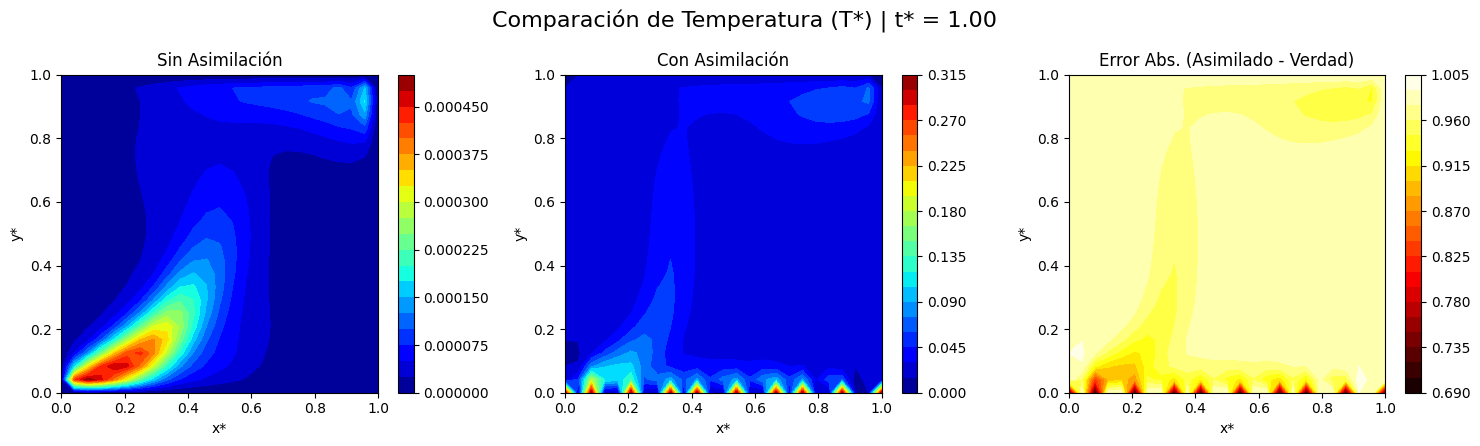

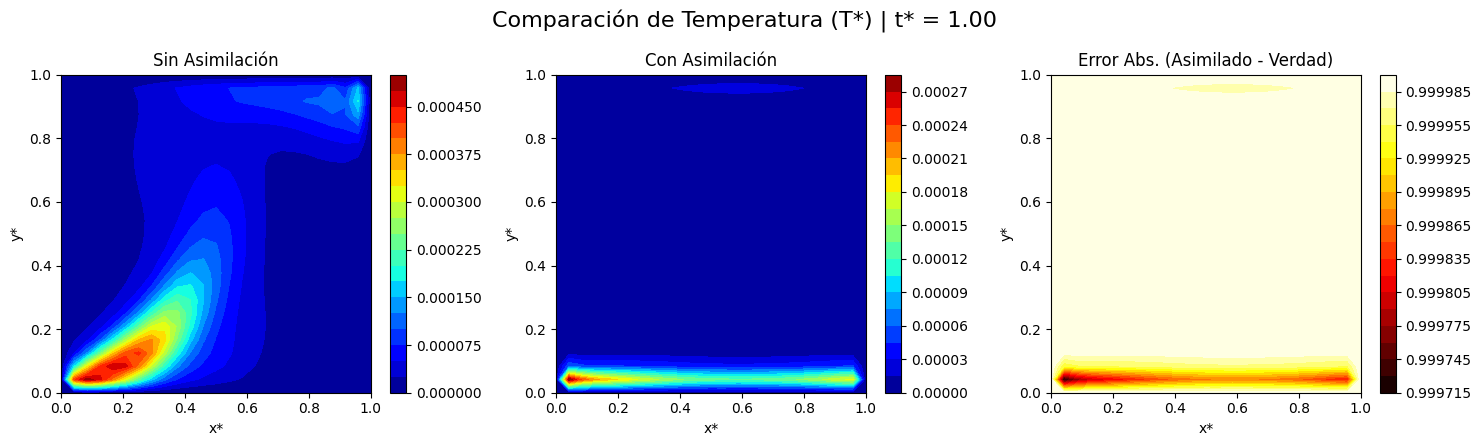

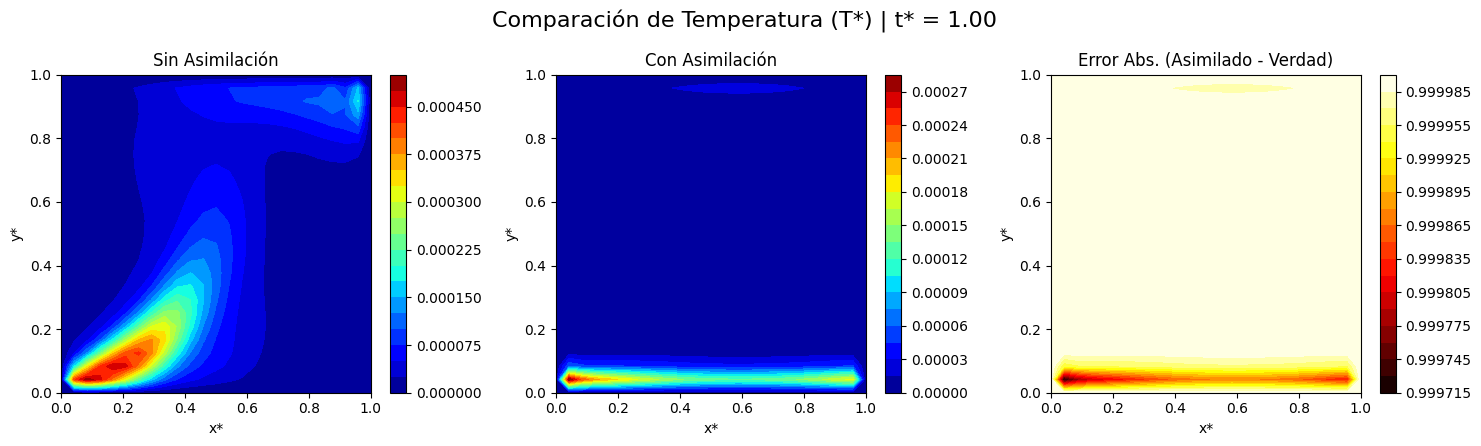

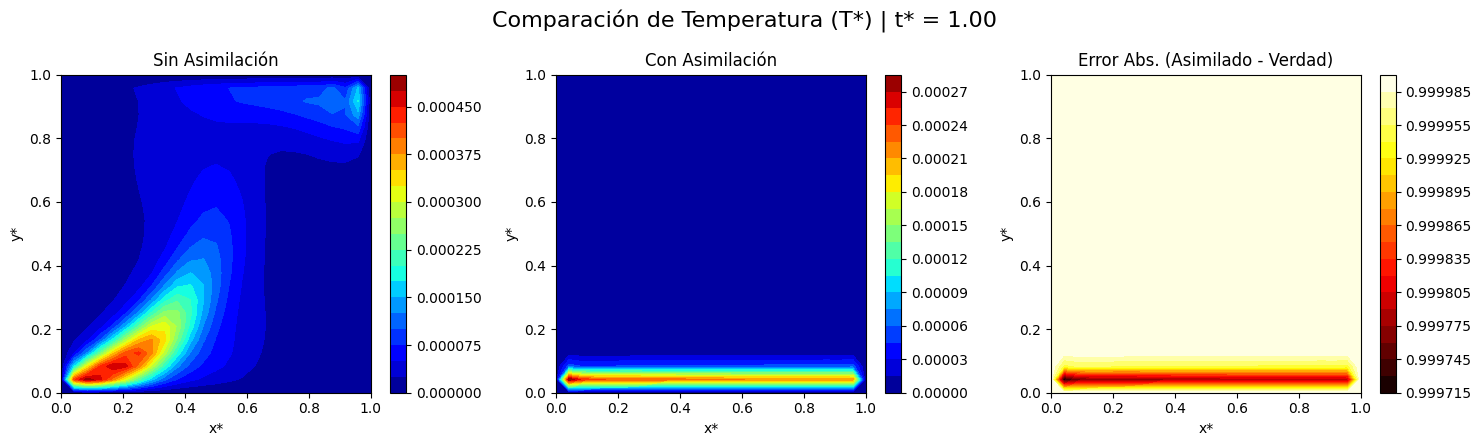

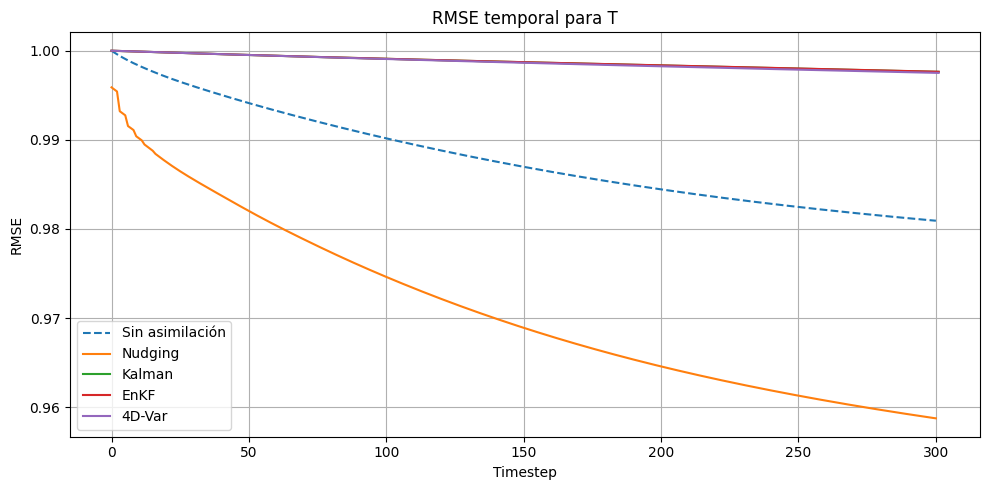

In [11]:
# ------------------ PARÁMETROS GENERALES ------------------
size = 25
variable = 'T'
nombre_sim = f"{size}x{size}"
ruido_std = 0.01
N_sens = 10
T_sens = 6
np.random.seed(42)

# ------------------ PARÁMETROS POR MÉTODO ------------------
params = {
    "nudging": {"alpha": 0.3},
    "kf": {"sigma_obs": 0.01, "sigma_modelo": 1e-4},
    "enkf": {"N_ens": 10, "sigma_obs": 0.01, "sigma_modelo": 1e-4},
    "4dvar": {"ventana": 5, "n_iter": 10, "alpha": 1e-2}
}

# ------------------ RUTAS ------------------
output_dir = f"DA/{nombre_sim}_{variable}"
os.makedirs(output_dir, exist_ok=True)

rutas = {
    metodo: {
        "datos": os.path.join(output_dir, f"{metodo}_{nombre_sim}.pkl"),
        "video": os.path.join(output_dir, f"{metodo}_{nombre_sim}_{variable}.mp4")
    }
    for metodo in ["nudging", "kf", "enkf", "4dvar"]
}

# ------------------ CARGA Y OBSERVACIONES ------------------
with open("sim_separacion/800x800.pkl", "rb") as f:
    resultados_ref = pickle.load(f)

with open("sim_separacion/25x25.pkl", "rb") as g:
    resultados_base = pickle.load(g)

obs = extraer_observaciones(N_sens=N_sens, T_sens=T_sens, size=800, ruido_std=ruido_std)
obs_dict = {o["t"]: o for o in obs}

resultados_ref_interp = interpolar_resultados_completos(resultados_ref, resultados_base)

# ------------------ MÉTODOS DE ASIMILACIÓN ------------------
resultados_dict = {}

# NUDGING
res_nudging = run_nudging(
    nx=size, ny=size,
    observaciones_dict=obs_dict,
    variables_asimilar=[variable],
    alpha=params["nudging"]["alpha"]
)
with open(rutas["nudging"]["datos"], "wb") as f:
    pickle.dump(res_nudging, f)
anim, _ = animar_comparacion(resultados_base, res_nudging, resultados_ref_interp, variable)
anim.save(rutas["nudging"]["video"], writer=FFMpegWriter(fps=10))
resultados_dict["Nudging"] = res_nudging

# KALMAN FILTER
res_kf = run_kalman(
    nx=size, ny=size,
    observaciones_dict=obs_dict,
    variables_asimilar=[variable],
    sigma_obs=params["kf"]["sigma_obs"],
    sigma_modelo=params["kf"]["sigma_modelo"]
)
with open(rutas["kf"]["datos"], "wb") as f:
    pickle.dump(res_kf, f)
anim, _ = animar_comparacion(resultados_base, res_kf, resultados_ref_interp, variable)
anim.save(rutas["kf"]["video"], writer=FFMpegWriter(fps=10))
resultados_dict["Kalman"] = res_kf

# ENSEMBLE KALMAN FILTER
res_enkf = run_enkf(
    nx=size, ny=size,
    N_ens=params["enkf"]["N_ens"],
    observaciones_dict=obs_dict,
    variables_asimilar=[variable],
    sigma_obs=params["enkf"]["sigma_obs"],
    sigma_modelo=params["enkf"]["sigma_modelo"]
)
with open(rutas["enkf"]["datos"], "wb") as f:
    pickle.dump(res_enkf, f)
anim, _ = animar_comparacion(resultados_base, res_enkf, resultados_ref_interp, variable)
anim.save(rutas["enkf"]["video"], writer=FFMpegWriter(fps=10))
resultados_dict["EnKF"] = res_enkf

# 4D-VAR
res_4dvar = run_4dvar(
    nx=size, ny=size,
    observaciones_dict=obs_dict,
    variables_asimilar=[variable],
    ventana=params["4dvar"]["ventana"],
    n_iter=params["4dvar"]["n_iter"],
    alpha=params["4dvar"]["alpha"]
)
with open(rutas["4dvar"]["datos"], "wb") as f:
    pickle.dump(res_4dvar, f)
anim, _ = animar_comparacion(resultados_base, res_4dvar, resultados_ref_interp, variable)
anim.save(rutas["4dvar"]["video"], writer=FFMpegWriter(fps=10))
resultados_dict["4D-Var"] = res_4dvar

# ------------------ COMPARACIÓN FINAL ------------------
comparar_resultados(resultados_base, resultados_dict, resultados_ref_interp, variable=variable)


In [12]:
# Carga
with open("sim_separacion/800x800.pkl", "rb") as f: ref_data = pickle.load(f)
with open("DA/25x25_T/nudging_25x25.pkl", "rb") as f: nudging = pickle.load(f)
with open("DA/25x25_T/kf_25x25.pkl", "rb") as f: kf = pickle.load(f)
with open("DA/25x25_T/enkf_25x25.pkl", "rb") as f: enkf = pickle.load(f)
with open("DA/25x25_T/4dvar_25x25.pkl", "rb") as f: var4d = pickle.load(f)

# Interpolar referencia a 25x25
ref_interp = {
    "X_star": nudging["X_star"],
    "Y_star": nudging["Y_star"],
    "T_history": interpolar_historial(ref_data["T_history"], ref_data["X_star"], ref_data["Y_star"], nudging["X_star"], nudging["Y_star"]),
    "p_history": interpolar_historial(ref_data["p_history"], ref_data["X_star"], ref_data["Y_star"], nudging["X_star"], nudging["Y_star"]),
    "tau_history": interpolar_historial(ref_data["tau_history"], ref_data["X_star"], ref_data["Y_star"], nudging["X_star"], nudging["Y_star"]),
    "u_history": interpolar_historial(ref_data["u_history"], ref_data["X_star"], ref_data["Y_star"], nudging["X_star"], nudging["Y_star"]),
    "v_history": interpolar_historial(ref_data["v_history"], ref_data["X_star"], ref_data["Y_star"], nudging["X_star"], nudging["Y_star"]),
}


In [13]:
animar_variables_vs_referencia(ref_interp, nudging, metodo='Nudging')
animar_variables_vs_referencia(ref_interp, enkf, metodo='EnKF')
animar_variables_vs_referencia(ref_interp, kf, metodo='KF')
animar_variables_vs_referencia(ref_interp, var4d, metodo='4DVAR')


🎞️ Animación guardada en: animaciones_diferencias/Nudging_4campos_diff.mp4
🎞️ Animación guardada en: animaciones_diferencias/EnKF_4campos_diff.mp4
🎞️ Animación guardada en: animaciones_diferencias/KF_4campos_diff.mp4
🎞️ Animación guardada en: animaciones_diferencias/4DVAR_4campos_diff.mp4


In [14]:
animar_campos_simulacion(ref_interp, metodo='Referencia')
animar_campos_simulacion(nudging, metodo='Nudging')
animar_campos_simulacion(enkf, metodo='EnKF')
animar_campos_simulacion(kf, metodo='KF')
animar_campos_simulacion(var4d, metodo='4DVAR')


🎞️ Animación guardada en: animaciones_campos/Referencia_campos.mp4
🎞️ Animación guardada en: animaciones_campos/Nudging_campos.mp4
🎞️ Animación guardada en: animaciones_campos/EnKF_campos.mp4
🎞️ Animación guardada en: animaciones_campos/KF_campos.mp4
🎞️ Animación guardada en: animaciones_campos/4DVAR_campos.mp4


ValueError: x and y must have same first dimension, but have shapes (302,) and (301,)

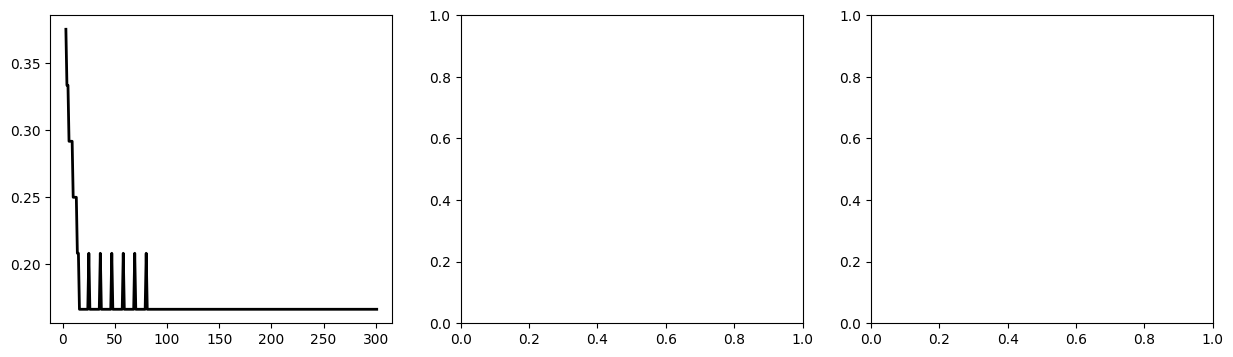

In [15]:
# 1. Calcular parámetros
param_ref = calcular_parametros_evolucion(ref_interp)
param_nudging = calcular_parametros_evolucion(nudging)
param_kf = calcular_parametros_evolucion(kf)
param_enkf = calcular_parametros_evolucion(enkf)
param_4dvar = calcular_parametros_evolucion(var4d)

# 2. Agrupar los métodos en un diccionario
params_dict = {
    'Nudging': param_nudging,
    'KF': param_kf,
    'EnKF': param_enkf,
    '4DVAR': param_4dvar
}

# 3. Graficar
graficar_evolucion_parametros_todos(param_ref, params_dict)


# Comprobar el error

In [14]:
def calcular_rmse_interpolacion(ref_data, ref_interp, variable='T'):
    """
    Compara la referencia original (800x800) con la interpolada (25x25)
    para verificar si la interpolación introduce errores significativos.
    """
    from scipy.interpolate import RegularGridInterpolator

    X_orig, Y_orig = ref_data['X_star'], ref_data['Y_star']
    X_new, Y_new = ref_interp['X_star'], ref_interp['Y_star']
    hist_orig = ref_data[f"{variable.lower()}_history"]
    hist_interp = ref_interp[f"{variable.lower()}_history"]

    nframes = min(len(hist_orig), len(hist_interp))
    errors = []

    for i in range(nframes):
        interpolador = RegularGridInterpolator((Y_orig[:,0], X_orig[0,:]), hist_orig[i])
        puntos = np.stack([Y_new.ravel(), X_new.ravel()], axis=-1)
        interp_vals = interpolador(puntos).reshape(X_new.shape)
        rmse = np.sqrt(np.mean((hist_interp[i] - interp_vals) ** 2))
        errors.append(rmse)

    return errors

def plot_diferencia_frame(ref, metodo, variable='T', frame=0):
    ref_v = ref[f"{variable.lower()}_history"][frame]
    met_v = metodo[f"{variable.lower()}_history"][frame]
    diff = np.abs(met_v - ref_v)

    plt.figure(figsize=(6, 5))
    plt.contourf(ref["X_star"], ref["Y_star"], diff, levels=20, cmap="hot")
    plt.colorbar()
    plt.title(f"Diferencia |{variable}| en frame {frame}")
    plt.xlabel("x*")
    plt.ylabel("y*")
    plt.show()

def calcular_rmse_temporal(ref_hist, pred_hist):
    return [np.sqrt(np.mean((r - p) ** 2)) for r, p in zip(ref_hist, pred_hist)]

import os
import pickle

def cargar_datos_simulacion_y_asimilacion(
    carpeta_simulacion="sim_separacion",
    carpeta_asimilacion="DA/25x25_T"
):
    """
    Carga los datos de simulación de referencia y los resultados de asimilación
    desde las carpetas especificadas.

    Retorna:
    --------
    - ref_data: dict con simulación 800x800
    - datos_asimilacion: dict con claves {'Nudging', 'KF', 'EnKF', '4DVar'}
    """
    # --- Cargar referencia 800x800 ---
    ref_path = os.path.join(carpeta_simulacion, "800x800.pkl")
    with open(ref_path, "rb") as f:
        ref_data = pickle.load(f)

    # --- Cargar métodos de asimilación ---
    archivos = {
        "Nudging": "nudging_25x25.pkl",
        "KF": "kf_25x25.pkl",
        "EnKF": "enkf_25x25.pkl",
        "4DVar": "4dvar_25x25.pkl"
    }

    datos_asimilacion = {}
    for metodo, archivo in archivos.items():
        path = os.path.join(carpeta_asimilacion, archivo)
        if not os.path.exists(path):
            print(f"⚠️ Archivo no encontrado para {metodo}: {archivo}")
            continue
        with open(path, "rb") as f:
            datos_asimilacion[metodo] = pickle.load(f)

    return ref_data, datos_asimilacion

def calcular_rmse_interpolacion(ref_data, ref_interp, variable='T'):
    """
    Compara la referencia original (800x800) con la interpolada (25x25)
    para verificar si la interpolación introduce errores significativos.
    """
    from scipy.interpolate import RegularGridInterpolator

    var_key = f"{variable}_history"  # respeta mayúsculas si las hay
    if var_key not in ref_data or var_key not in ref_interp:
        raise KeyError(f"La variable '{var_key}' no existe en los datos proporcionados.")

    X_orig, Y_orig = ref_data['X_star'], ref_data['Y_star']
    X_new, Y_new = ref_interp['X_star'], ref_interp['Y_star']
    hist_orig = ref_data[var_key]
    hist_interp = ref_interp[var_key]

    nframes = min(len(hist_orig), len(hist_interp))
    errors = []

    for i in range(nframes):
        interpolador = RegularGridInterpolator((Y_orig[:, 0], X_orig[0, :]), hist_orig[i])
        puntos = np.stack([Y_new.ravel(), X_new.ravel()], axis=-1)
        interp_vals = interpolador(puntos).reshape(X_new.shape)
        rmse = np.sqrt(np.mean((hist_interp[i] - interp_vals) ** 2))
        errors.append(rmse)

    return errors



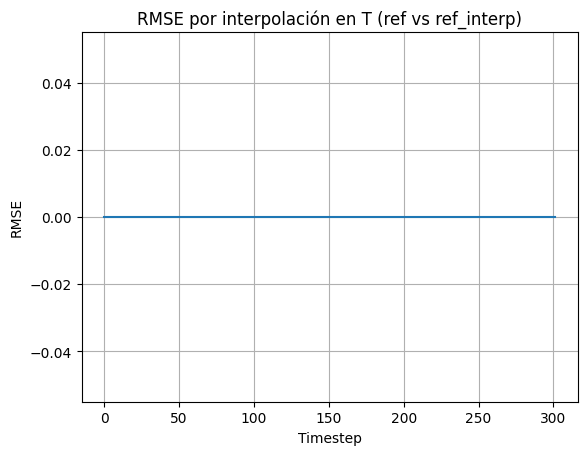

In [15]:
ref_data, datos_asimilacion = cargar_datos_simulacion_y_asimilacion()

# Acceder a cada método:
nudging = datos_asimilacion['Nudging']
kf      = datos_asimilacion['KF']
enkf    = datos_asimilacion['EnKF']
var4d   = datos_asimilacion['4DVar']

X_dest = nudging["X_star"]
Y_dest = nudging["Y_star"]

ref_interp = {
    "X_star": X_dest,
    "Y_star": Y_dest,
    "T_history": interpolar_historial(ref_data["T_history"], ref_data["X_star"], ref_data["Y_star"], X_dest, Y_dest),
    "p_history": interpolar_historial(ref_data["p_history"], ref_data["X_star"], ref_data["Y_star"], X_dest, Y_dest),
    "tau_history": interpolar_historial(ref_data["tau_history"], ref_data["X_star"], ref_data["Y_star"], X_dest, Y_dest),
    "u_history": interpolar_historial(ref_data["u_history"], ref_data["X_star"], ref_data["Y_star"], X_dest, Y_dest),
    "v_history": interpolar_historial(ref_data["v_history"], ref_data["X_star"], ref_data["Y_star"], X_dest, Y_dest)
}


rmse_interp_T = calcular_rmse_interpolacion(ref_data, ref_interp, variable='T')
plt.plot(rmse_interp_T)
plt.title("RMSE por interpolación en T (ref vs ref_interp)")
plt.xlabel("Timestep")
plt.ylabel("RMSE")
plt.grid()
plt.show()


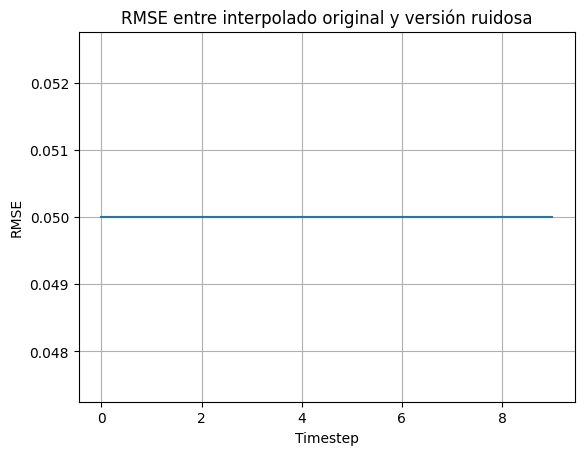

In [16]:
# Simular una malla de referencia y un campo sintético
ny, nx = 100, 100
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X_ref, Y_ref = np.meshgrid(x, y)
campo = np.sin(np.pi * X_ref) * np.cos(np.pi * Y_ref)

# Simular historial temporal (repetimos el mismo campo con pequeñas variaciones)
hist_ref = [campo + 0.01 * np.random.randn(ny, nx) for _ in range(10)]

# Crear malla más gruesa (destino)
ny_dest, nx_dest = 25, 25
x_dest = np.linspace(0, 1, nx_dest)
y_dest = np.linspace(0, 1, ny_dest)
X_dest, Y_dest = np.meshgrid(x_dest, y_dest)

# Usamos tu función corregida de interpolación
from scipy.interpolate import RegularGridInterpolator

def interpolar_historial(hist_ref, X_ref, Y_ref, X_dest, Y_dest):
    x_ref = X_ref[0, :]
    y_ref = Y_ref[:, 0]
    puntos_destino = np.stack([Y_dest.ravel(), X_dest.ravel()], axis=-1)

    historial_interp = []
    for campo in hist_ref:
        interpolador = RegularGridInterpolator((y_ref, x_ref), campo)
        campo_interp = interpolador(puntos_destino).reshape(X_dest.shape)
        historial_interp.append(campo_interp)

    return historial_interp

# Interpolamos
hist_interp = interpolar_historial(hist_ref, X_ref, Y_ref, X_dest, Y_dest)

# Ahora añadimos ruido artificial a los interpolados para verificar si el RMSE lo capta
hist_interp_ruidoso = [c + 0.05 for c in hist_interp]

# Calcular RMSE entre interpolación ruidosa y la interpolación base
rmse = [np.sqrt(np.mean((a - b) ** 2)) for a, b in zip(hist_interp, hist_interp_ruidoso)]

# Mostrar
plt.plot(rmse)
plt.title("RMSE entre interpolado original y versión ruidosa")
plt.xlabel("Timestep")
plt.ylabel("RMSE")
plt.grid()
plt.show()


In [19]:
def verificar_causas_rmse_alto(ref_interp, metodo_data, nombre_metodo="Método", variable='T'):
    """
    Diagnóstico paso a paso para verificar causas de RMSE alto entre referencia y método de asimilación.
    """
    """
    Diagnóstico paso a paso para verificar causas de RMSE alto entre referencia y método de asimilación.
    
    Parámetros:
    -----------
    ref_interp : dict
        Datos de referencia interpolados (p. ej. 25x25)
    metodo_data : dict
        Datos del método de asimilación (nudging, EnKF, etc.)
    nombre_metodo : str
        Nombre del método, usado para etiquetas
    variable : str
        Variable a evaluar ('T', 'p', 'tau', etc.)
    """
    var_key = f"{variable}_history"  # Usar capitalización exacta

    print("▶ Paso 1: Comparar dimensiones espaciales (X*, Y*)")
    same_shape = ref_interp['X_star'].shape == metodo_data['X_star'].shape
    same_values = np.allclose(ref_interp['X_star'], metodo_data['X_star']) and np.allclose(ref_interp['Y_star'], metodo_data['Y_star'])
    print(f"   - Formas iguales: {same_shape}")
    print(f"   - Valores iguales: {same_values}\n")

    print("▶ Paso 2: Comparar número de timesteps")
    n_ref = len(ref_interp[var_key])
    n_met = len(metodo_data[var_key])
    print(f"   - Ref: {n_ref} frames | {nombre_metodo}: {n_met} frames")
    if n_ref != n_met:
        print("⚠️ Diferente número de frames. Puede generar desalineamiento temporal.\n")
    else:
        print("   - ✅ Coinciden\n")

    print("▶ Paso 3: Ver diferencias en el primer frame")
    plt.figure(figsize=(10,4))
    diff = np.abs(ref_interp[var_key][0] - metodo_data[var_key][0])
    plt.contourf(ref_interp['X_star'], ref_interp['Y_star'], diff, levels=20, cmap='hot')
    plt.colorbar(label=f'|{variable}| error en frame 0')
    plt.title(f'Diferencia {variable} (frame 0) - {nombre_metodo}')
    plt.xlabel("x*")
    plt.ylabel("y*")
    plt.tight_layout()
    plt.show()

    print("▶ Paso 4: Comparar RMSE temporal")
    rmse = [np.sqrt(np.mean((r - m)**2)) for r, m in zip(ref_interp[var_key], metodo_data[var_key])]
    plt.figure(figsize=(8,4))
    plt.plot(rmse, label=f'RMSE {variable} ({nombre_metodo})')
    plt.xlabel("Timestep")
    plt.ylabel("RMSE")
    plt.title(f"RMSE temporal para {variable} - {nombre_metodo}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("▶ Paso 5: ¿Se asimila solo T?")
    if "asimiladas" in metodo_data:
        print(f"   - Variables asimiladas: {metodo_data['asimiladas']}")
    else:
        print("   - No se especificó 'asimiladas'. Asumiendo solo 'T'.")

    print("\n✅ Revisión básica completa.\n")


▶ Paso 1: Comparar dimensiones espaciales (X*, Y*)
   - Formas iguales: True
   - Valores iguales: True

▶ Paso 2: Comparar número de timesteps
   - Ref: 302 frames | Nudging: 301 frames
⚠️ Diferente número de frames. Puede generar desalineamiento temporal.

▶ Paso 3: Ver diferencias en el primer frame


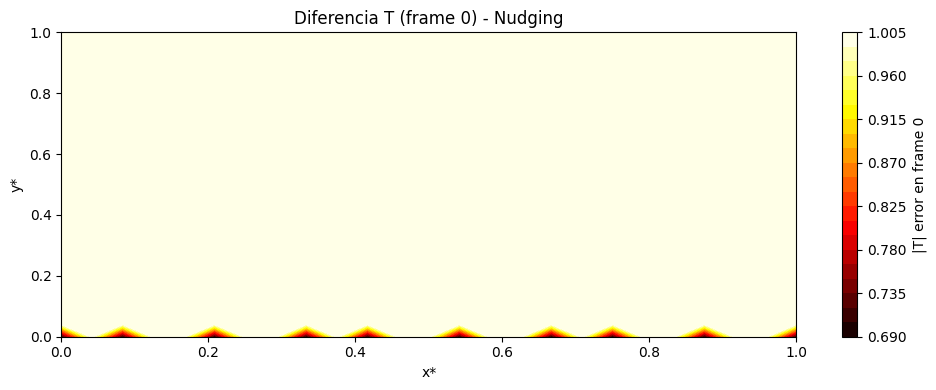

▶ Paso 4: Comparar RMSE temporal


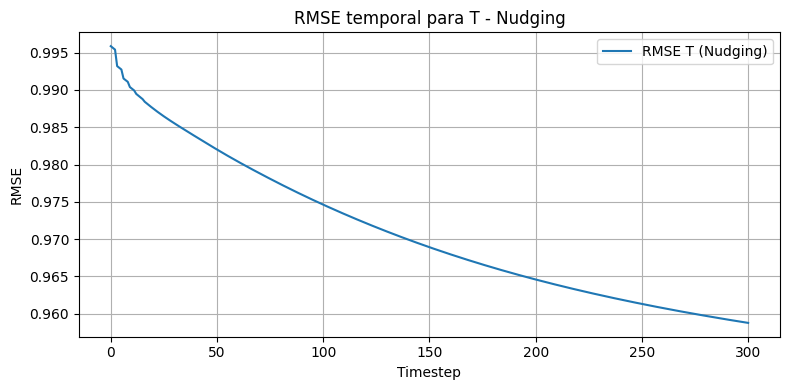

▶ Paso 5: ¿Se asimila solo T?
   - No se especificó 'asimiladas'. Asumiendo solo 'T'.

✅ Revisión básica completa.

▶ Paso 1: Comparar dimensiones espaciales (X*, Y*)
   - Formas iguales: True
   - Valores iguales: True

▶ Paso 2: Comparar número de timesteps
   - Ref: 302 frames | EnKF: 6000 frames
⚠️ Diferente número de frames. Puede generar desalineamiento temporal.

▶ Paso 3: Ver diferencias en el primer frame


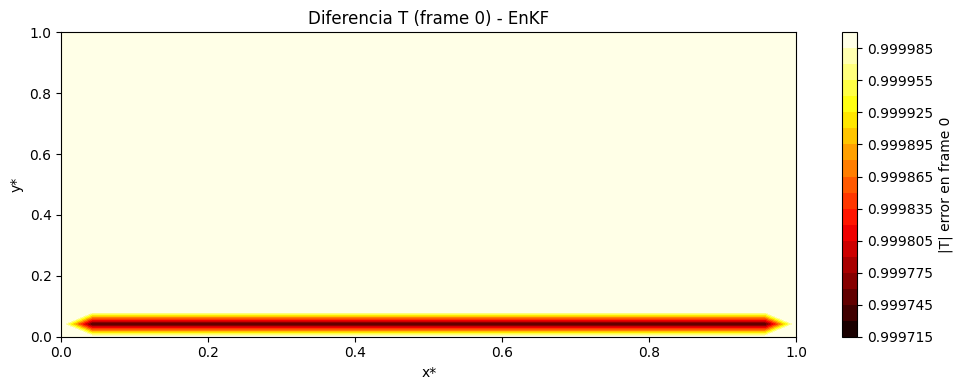

▶ Paso 4: Comparar RMSE temporal


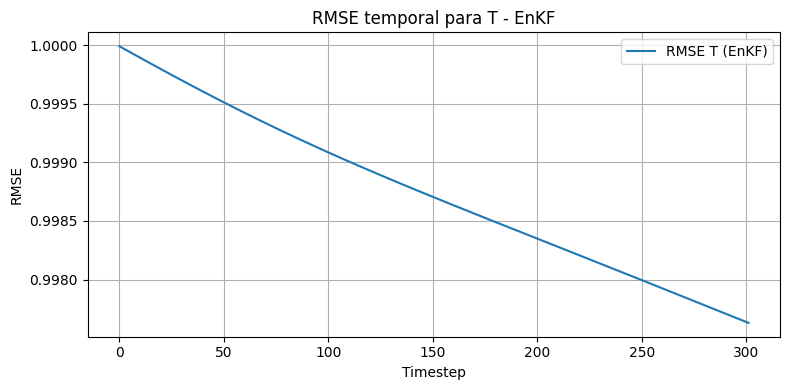

▶ Paso 5: ¿Se asimila solo T?
   - No se especificó 'asimiladas'. Asumiendo solo 'T'.

✅ Revisión básica completa.



In [20]:
verificar_causas_rmse_alto(ref_interp, nudging, nombre_metodo="Nudging", variable='T')
verificar_causas_rmse_alto(ref_interp, enkf, nombre_metodo="EnKF", variable='T')
